model comparison - wine dataset
----------------------------------------
knn -> 0.944
logistic regression -> 1.0
decision tree -> 0.944


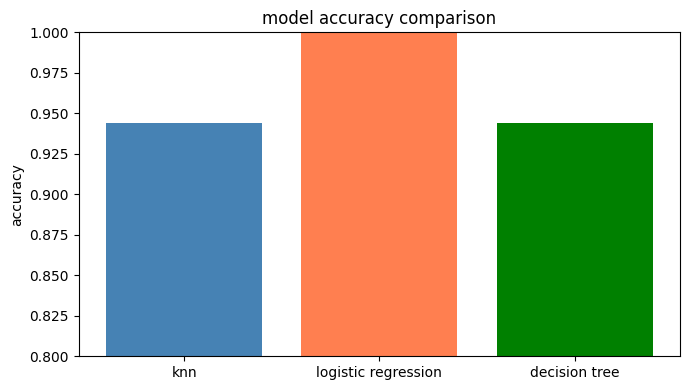

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

wine = load_wine()
x = wine.data
y = wine.target

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

models = {
    "knn":                 KNeighborsClassifier(n_neighbors=5),
    "logistic regression": LogisticRegression(max_iter=1000),
    "decision tree":       DecisionTreeClassifier(max_depth=4, random_state=42)
}

print("model comparison - wine dataset")
print("-" * 40)

scores = {}
for name, model in models.items():
    model.fit(x_train, y_train)
    score = round(accuracy_score(y_test, model.predict(x_test)), 3)
    scores[name] = score
    print(name, "->", score)

plt.figure(figsize=(7, 4))
plt.bar(scores.keys(), scores.values(), color=["steelblue", "coral", "green"])
plt.title("model accuracy comparison")
plt.ylabel("accuracy")
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()